# Prédictions Trading avec Random Forest

In [1]:
#imports pour random forest
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

In [9]:
# --- 1. Chargement et préparation des données ---

# Charger le fichier CSV avec les données préformatées
df = pd.read_csv('Data/cac40_clean_format.csv', parse_dates=['Datetime'])
df.sort_values(by=['Ticker', 'Price', 'Datetime'], inplace=True)
print(df.columns)

# Pivot du DataFrame pour obtenir une colonne par type de prix.
df_wide = df.pivot_table(index=['Datetime', 'Ticker'], columns='Price', values='Value').reset_index()
# Vérification des colonnes après pivot (on doit avoir une colonne 'Close' issue de la colonne 'Price')
print(df_wide.columns)

Index(['Datetime', 'Price', 'Ticker', 'Value'], dtype='object')
Index(['Datetime', 'Ticker', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [11]:
# --- 2. Définition des labels ---

# Ici, nous allons utiliser la colonne 'Close' pour calculer le rendement.
# On trie par date pour être sûr que les calculs temporels sont corrects.
df_wide = df_wide.sort_values('Datetime')

seuil = 0.01

# Calcul du rendement du jour suivant à partir du prix de clôture
df_wide['return'] = df_wide['Close'].shift(-1) / df_wide['Close'] - 1

# Création d'un label binaire : 1 si le rendement est supérieur ou égal au seuil, sinon 0
df_wide['label'] = (df_wide['return'] >= seuil).astype(int)

# Suppression de la dernière ligne, car le rendement n'est pas défini (shift crée une valeur NaN)
df_wide.dropna(subset=['return'], inplace=True)

# Afficher quelques lignes où le label est 1
print(df_wide[df_wide['label'] == 1].head())

Price                  Datetime  Ticker       Close        High         Low  \
22    2023-03-14 08:00:00+00:00   MT.AS   26.950001   26.980000   26.594999   
24    2023-03-14 08:00:00+00:00  ORA.PA   10.718000   10.746000   10.620000   
25    2023-03-14 08:00:00+00:00  PUB.PA   72.620003   72.699997   72.019997   
26    2023-03-14 08:00:00+00:00   RI.PA  197.399994  197.949997  196.649994   
21    2023-03-14 08:00:00+00:00   ML.PA   27.820000   27.895000   27.580000   

Price        Open  Volume     return  label  
22      26.844999     0.0  12.905380      1  
24      10.732000     0.0   5.775518      1  
25      72.059998     0.0   1.718259      1  
26     196.949997     0.0   7.677812      1  
21      27.830000     0.0   2.189432      1  


In [ ]:
# --- 3. Définition des features ---

# On utilise les colonnes de prix et volume, et éventuellement des indicateurs techniques si disponibles
features = ['Open', 'High', 'Low', 'Close', 'Volume']
if 'RSI' in df_wide.columns:
    features.append('RSI')
if 'MACD' in df_wide.columns:
    features.append('MACD')

In [ ]:
X = df_wide[features]
y = df_wide['label']

# --- 4. Séparation train/test ---

print("Nombre total d'échantillons :", len(df_wide))

# Calcul de la taille du training set à 70%
train_size = int(0.7 * len(df_wide))
print("Taille train :", train_size, "Taille test :", len(df_wide) - train_size)

# Séparation en gardant l'ordre chronologique
X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

Nombre total d'échantillons : 187346
Taille train : 131142 Taille test : 56204


In [19]:
# --- 5. Entraînement du modèle RandomForest ---

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prédiction sur l'ensemble de test
y_pred = rf.predict(X_test)

# Évaluation du modèle
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7581310938723222
              precision    recall  f1-score   support

           0       0.78      0.79      0.79     31720
           1       0.72      0.72      0.72     24484

    accuracy                           0.76     56204
   macro avg       0.75      0.75      0.75     56204
weighted avg       0.76      0.76      0.76     56204



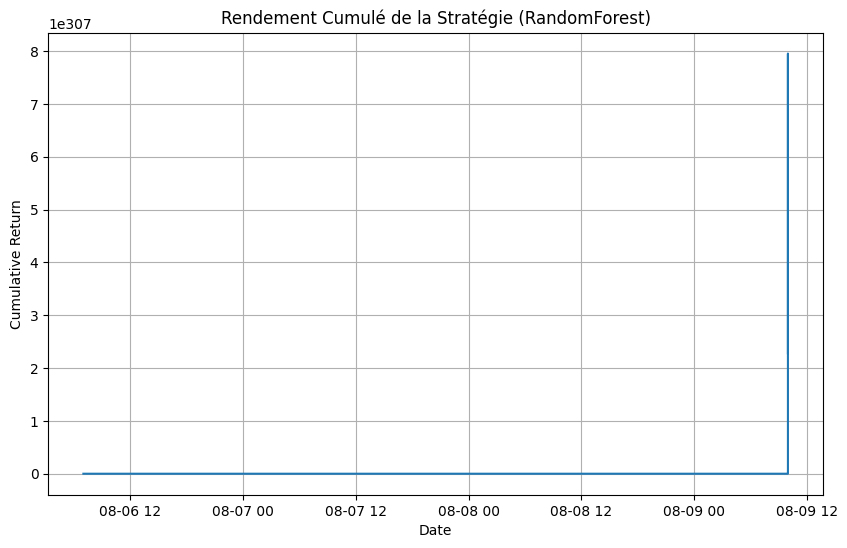

In [26]:
# --- 6. Backtesting de la stratégie ---

# On part du principe que X_test a été défini à partir de df_wide
# Récupérer les dates correspondant à X_test (en utilisant les index)
test_dates = df_wide.loc[X_test.index, 'Datetime']

# Nous simulons une stratégie : si le modèle prédit 1, on "achète" et on récupère le rendement du jour suivant.
# On récupère la colonne 'return' pour la période de test.
X_test = X_test.copy()
X_test['pred'] = y_pred

# Les rendements réels sur le test
X_test['return'] = df_wide['return'].iloc[train_size:].values

# Rendement de la stratégie : si le signal est 1, appliquer le rendement du jour suivant, sinon 0
X_test['strategy_return'] = X_test['pred'] * X_test['return']

# Calcul du rendement cumulé de la stratégie
X_test['cumulative_return'] = (1 + X_test['strategy_return']).cumprod()

# Visualisation du rendement cumulé
plt.figure(figsize=(10,6))
plt.plot(test_dates.values, X_test['cumulative_return'])
plt.title("Rendement Cumulé de la Stratégie (RandomForest)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


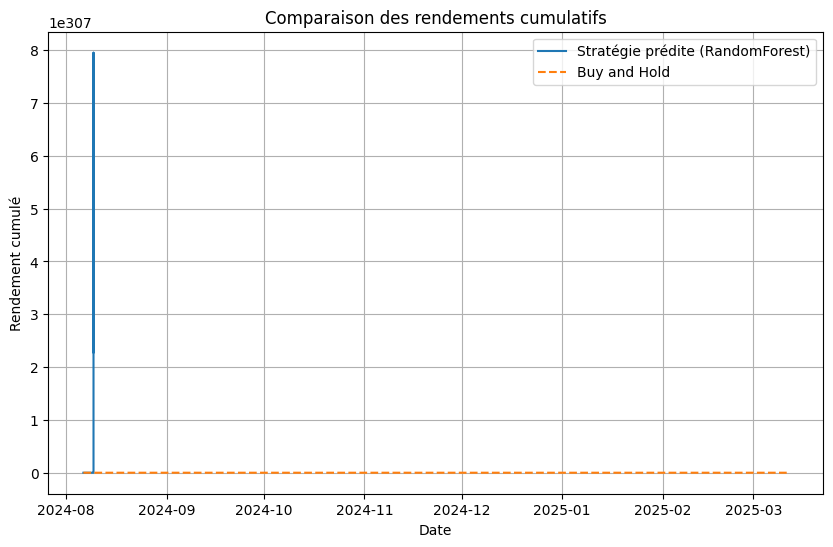

In [29]:
#Autres tests de la stratégie:

# On part du DataFrame pivoté df_wide qui contient la colonne 'Date' et 'return'
# On sélectionne la période de test (les 30% finaux)
df_test = df_wide.iloc[train_size:].copy()

# Ajout des prédictions du modèle (y_pred issu du RandomForest)
df_test['pred'] = y_pred

# Calcul du rendement de la stratégie :
# Si la prédiction est 1 (signal d'achat), on applique le rendement du jour suivant, sinon 0.
df_test['strategy_return'] = df_test['pred'] * df_test['return']

# Calcul du rendement cumulé de la stratégie
df_test['cumulative_return'] = (1 + df_test['strategy_return']).cumprod()

# Pour comparaison, calcul du rendement cumulé en cas de Buy and Hold
df_test['buy_hold_return'] = (1 + df_test['return']).cumprod()

# Visualisation : comparaison du rendement cumulé de la stratégie et du Buy and Hold
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df_test['Datetime'], df_test['cumulative_return'], label='Stratégie prédite (RandomForest)')
plt.plot(df_test['Datetime'], df_test['buy_hold_return'], label='Buy and Hold', linestyle='--')
plt.title("Comparaison des rendements cumulatifs")
plt.xlabel("Date")
plt.ylabel("Rendement cumulé")
plt.legend()
plt.grid(True)
plt.show()